# Phase 5: Hyperparameter Tuning & Interpretation

Tunes Logistic Regression's regularization strength via GridSearchCV,
interprets which words drive its predictions, and saves the final tuned
model + vectorizer for Phase 6 (and the demo app).

In [1]:
import warnings
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42

bundle = joblib.load("../data/features_bundle.joblib")
X_train_tfidf = bundle["X_train_tfidf"]
X_test_tfidf = bundle["X_test_tfidf"]
y_train = bundle["y_train"]
y_test = bundle["y_test"]
tfidf = bundle["tfidf_vectorizer"]
print(f"Loaded features. Train: {X_train_tfidf.shape}, Test: {X_test_tfidf.shape}")

Loaded features. Train: (14304, 5000), Test: (3576, 5000)


## Hyperparameter tuning

A grid search (3-fold cross-validation, optimizing F1) over Logistic
Regression's regularization strength `C`.

In [2]:
def get_scores(model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_score = model.predict_proba(X_te)[:, 1]
    return {
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1": f1_score(y_te, y_pred),
        "ROC-AUC": roc_auc_score(y_te, y_score),
    }

param_grid = {"C": [0.1, 1, 5, 10]}
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    param_grid, scoring="f1", cv=3, n_jobs=-1
)
grid_search.fit(X_train_tfidf, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV F1: {grid_search.best_score_:.4f}")

best_lr = grid_search.best_estimator_
tuned_scores = get_scores(best_lr, X_test_tfidf, y_test)
print("\nTuned Logistic Regression test performance:")
print(pd.Series(tuned_scores).round(4))

Best params: {'C': 10}
Best CV F1: 0.7508

Tuned Logistic Regression test performance:
Accuracy     0.9799
Precision    0.7590
Recall       0.8555
F1           0.8043
ROC-AUC      0.9866
dtype: float64


## Model interpretation

Each TF-IDF feature has a signed coefficient in the linear model: positive
pushes toward "fraudulent", negative toward "legitimate".

In [3]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = best_lr.coef_[0]
top_fraud_idx = np.argsort(coefs)[-20:][::-1]
top_legit_idx = np.argsort(coefs)[:20]

print("Top 20 words/phrases pushing toward FRAUDULENT:")
for i in top_fraud_idx:
    print(f"  {feature_names[i]:<25} coef={coefs[i]:.3f}")

print("\nTop 20 words/phrases pushing toward LEGITIMATE:")
for i in top_legit_idx:
    print(f"  {feature_names[i]:<25} coef={coefs[i]:.3f}")

Top 20 words/phrases pushing toward FRAUDULENT:
  link                      coef=11.813
  aptitude                  coef=8.065
  high school               coef=7.138
  offshore                  coef=7.084
  amp experience            coef=6.078
  earn                      coef=6.038
  oil gas                   coef=6.013
  accountant                coef=5.957
  money                     coef=5.917
  clerk                     coef=5.438
  ohio                      coef=5.331
  ms word                   coef=5.195
  data entry                coef=5.141
  aker                      coef=5.112
  compensation package      coef=5.078
  duration                  coef=5.053
  signing                   coef=5.052
  financing                 coef=5.040
  cash                      coef=5.023
  time time                 coef=5.022

Top 20 words/phrases pushing toward LEGITIMATE:
  companies                 coef=-6.700
  english                   coef=-6.421
  team                      coef=-6.141
  

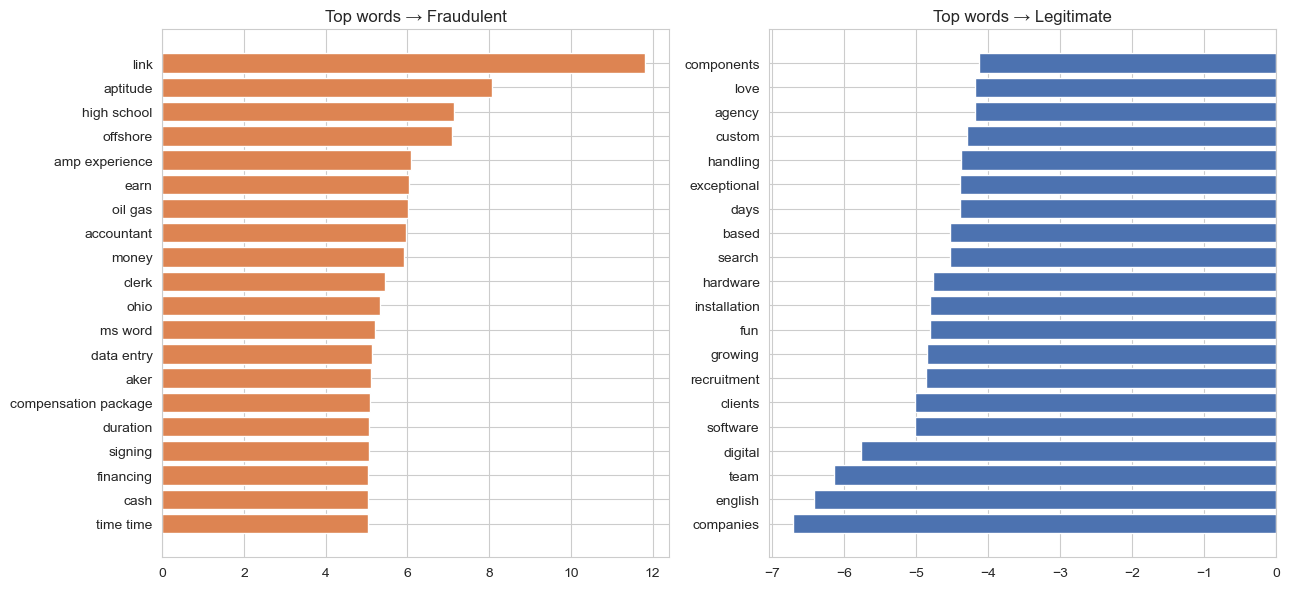

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].barh(feature_names[top_fraud_idx][::-1], coefs[top_fraud_idx][::-1], color="#DD8452")
axes[0].set_title("Top words → Fraudulent")
axes[1].barh(feature_names[top_legit_idx], coefs[top_legit_idx], color="#4C72B0")
axes[1].set_title("Top words → Legitimate")
plt.tight_layout()
plt.savefig("../figures/feature_importance.png", dpi=120)
plt.show()

## Save the tuned model + vectorizer

These are the final artifacts used by Phase 6 and the Streamlit demo app.

In [5]:
joblib.dump(best_lr, "../app/fraud_model.joblib")
joblib.dump(tfidf, "../app/tfidf_vectorizer.joblib")
print("Saved app/fraud_model.joblib and app/tfidf_vectorizer.joblib")

Saved app/fraud_model.joblib and app/tfidf_vectorizer.joblib
